In [49]:
import random
import matplotlib.pyplot as plt
import numpy as np

In [50]:
# parametros do AG
n_pop = 50
quantidade_genes = 50
n_geracoes = 150
pop = []
nova_pop = []
n_cortes = 1
taxa_crossover = 0.8
taxa_mutacao = 0.05
selecao='torneio'

# Random seed
random_seed = 42

# Parametros da sphere
n_dimensoes = quantidade_genes
var_min = -100
var_max = 100


# parametros do AG
n_pop = 50
quantidade_genes = 50
n_geracoes = 150
pop = []
nova_pop = []
n_cortes = 1
taxa_crossover = 0.8
taxa_mutacao = 0.05
selecao='torneio'

# Random seed
random_seed = 42

# Parametros da sphere
n_dimensoes = quantidade_genes
var_min = -100
var_max = 100


In [51]:
# Configurar seed para reprodutibilidade
random.seed(random_seed)
np.random.seed(random_seed)

pop.clear()
#Loop para criar cada indivíduo da população:
for i in range(n_pop):
    cromossomo = [random.uniform(var_min, var_max) for _ in range(n_dimensoes)]
    pop.append(cromossomo)
    #print(f"cromossomo {i+1} gerado: {cromossomo}")
    #print("\n")


In [52]:
#pop

## Função Sphere

In [53]:
def sphere(x):
    """
    Sphere Function
    Mínimo global: f(0, ..., 0) = 0
    """
    return sum(xi**2 for xi in x)

## Avaliar cada individuo 

In [54]:
pop_aval= []
pop_aval.clear()
for cromossomo in pop:
    nota_aval = sphere(cromossomo)
    pop_aval.append((cromossomo, nota_aval))

#pop_aval
    

## Selecionar os individuos mais aptos

In [55]:
def calcular_fitness(pop_avaliada):
    """
    Recebe: lista de tuplas (cromossomo, valor_sphere)
    Retorna: lista de pesos de fitness
    """
    return [1 / (1 + individuo[1]) for individuo in pop_avaliada]

#def mostrar_probabilidade(pop_avaliada):
#    """
#    Mostra cada cromossomo com sua avaliação e probabilidade relativa
#    """
#    fitness = calcular_fitness(pop_avaliada)
#    total = sum(fitness)
#    probabilidades = [f/total for f in fitness]
#
#    for i, (crom, fitness) in enumerate(pop_avaliada):
#        print(f"Cromossomo {i+1}: avaliação={fitness:.2f}, probabilidade={probabilidades[i]*100:.2f}%")

def selecao_proporcional(pop_avaliada, n_pop_selec):
    """
    Recebe: população avaliada e quantidade a selecionar
    Retorna: apenas os cromossomos selecionados (sem o valor da sphere)
    """
    fitness = calcular_fitness(pop_avaliada)

    grupo_survivors = random.choices(pop_avaliada, weights=fitness, k=n_pop_selec)
    
    # retorna só os cromossomos, sem o valor da sphere
    return [individuo[0] for individuo in grupo_survivors]

In [56]:
#mostrar_probabilidade(pop_aval)
#len(p1_survivors)

In [57]:
def selecao_torneio(pop_avaliada, n_pop_selec):
    """
    Recebe: população avaliada [(cromossomo, avaliação), ...]
    Retorna: lista de cromossomos selecionados via torneio
    """
    grupo_survivors = []
    for rodada in range(n_pop_selec):
        # sorteiar 2 competidores
        c1, c2 = random.choices(pop_avaliada, k=2)

        # mostrar os competidores
        #print(f"Torneio {rodada+1}:")
        #print(f"  Competidor 1 -> avaliação={c1[1]:.2f}")
        #print(f"  Competidor 2 -> avaliação={c2[1]:.2f}")

        # comparar avaliações (menor é melhor)
        if c1[1] < c2[1]:
            survivor = c1
        else:
            survivor = c2

        #print(f"  Vencedor -> avaliação={survivor[1]:.2f}\n")

        grupo_survivors.append(survivor[0])  # pega só o cromossomo

    return grupo_survivors

In [58]:
def selecionar_pais(selecao, pop_avaliada, n_pop_selec):
    """
    Recebe: lista de tuplas (cromossomo, valor_sphere)          
    :param selecao: 
    :param pop_avaliada: 
    :param n_pop_selec: 
    :return: lista de p1 e p2 selecionados
    """
    if selecao.lower().strip() == 'torneio':
        p1_survivors = selecao_torneio(pop_avaliada, n_pop_selec)
        p2_survivors= selecao_torneio(pop_avaliada, n_pop_selec)
    else:
        p1_survivors = selecao_proporcional(pop_avaliada, n_pop_selec)
        p2_survivors = selecao_proporcional(pop_avaliada, n_pop_selec)
    return p1_survivors, p2_survivors


In [59]:
def crossover_1pt(p1, p2, taxa_crossover, quantidade_genes):
    """
    Recebe: dois pais (Selecionados/sobreviventes), taxa de crossover e a quantidade de genes
    Retorna: dois filhos
    """
    # verifica se há cruzamento
    if random.random() < taxa_crossover:
        ponto_corte = random.randint(1, quantidade_genes - 1)
        
        # troca as partes após o ponto de corte
        filho1 = p1[:ponto_corte] + p2[ponto_corte:]
        filho2 = p2[:ponto_corte] + p1[ponto_corte:]
        #print(f"crossover: {filho1} + {filho2}\n")
    else:
        # sem cruzamento, filhos são cópias dos pais
        filho1 = p1[:]
        filho2 = p2[:]
        #print(f"sem crossover: {filho1} + {filho2}\n")
    
    return filho1, filho2

In [60]:
def mutacao(cromossomo, taxa_mutacao, quantidade_genes, var_min, var_max):
    """
    Recebe: cromossomo, quantidade de genes, taxa de mutação e limites
    Retorna: cromossomo (com possíveis mutações)
    """
    cromossomo_mutado = cromossomo[:]  # copia para não alterar o original
    
    for i in range(quantidade_genes):
        if random.random() < taxa_mutacao:
            cromossomo_mutado[i] = random.uniform(var_min, var_max)
            #print(f"mutacao no {i+1}: {cromossomo} ---> {cromossomo_mutado}\n")
    
    return cromossomo_mutado

In [61]:
def gerar_nova_pop(p1_survivors, p2_survivors, quantidade_genes,n_pop,
                          taxa_crossover, taxa_mutacao, 
                          var_min, var_max, nova_pop):
    """
    Recebe: listas de pais selecionados, quantidade de genes, a lista de nova populção, taxas e limites
    Retorna: nova população após crossover e mutação
    """
    
    # percorre os pais em pares
    for i in range(0, n_pop):
        
        p1 = random.choice(p1_survivors)
        p2 = random.choice(p2_survivors)
        
        # crossover
        filho1, filho2 = crossover_1pt(p1, p2, taxa_crossover, quantidade_genes)
        
        # mutação em cada filho
        filho1 = mutacao(filho1, taxa_mutacao, quantidade_genes, var_min, var_max)
        filho2 = mutacao(filho2, taxa_mutacao, quantidade_genes, var_min, var_max)
        
        nova_pop.append(filho1)
        nova_pop.append(filho2)
        
    return nova_pop

## Loop exec - Critério de parada - GERAÇÕES

In [62]:

# Listas para armazenar resultados de TODAS as 30 execuções
historico_melhor_all = []
historico_notas_all = []
melhor_fitness_por_exec = []

# Loop de 30 execuções com seeds variados (42-71)
for execucao in range(30):
    # Redefinir seed para reprodutibilidade com variação
    seed_atual = 42 + execucao
    random.seed(seed_atual)
    np.random.seed(seed_atual)
    
    # Reinicializar históricos para esta execução
    historico_melhor = []
    historico_notas = []
    
    # Gerar população inicial para esta execução
    pop.clear()
    for i in range(n_pop):
        cromossomo = [random.uniform(var_min, var_max) for _ in range(n_dimensoes)]
        pop.append(cromossomo)
    
    # Loop de gerações
    for geracao in range(n_geracoes):

       # 1. Avaliar população atual
        pop_aval = [(crom, sphere(crom)) for crom in pop]
        
        notas_avaliacao = [aval for _, aval in pop_aval]
        historico_notas.append(notas_avaliacao)

        # 2. Selecionar pais
        p1_survivors, p2_survivors = selecionar_pais(selecao, pop_aval, n_pop)

        # 3. Gerar 60 filhos
        nova_pop.clear()
        gerar_nova_pop(p1_survivors, p2_survivors, quantidade_genes, n_pop,
                       taxa_crossover, taxa_mutacao, var_min, var_max, nova_pop)

        # Avalia todos os 60 filhos
        filhos_aval = [(crom, sphere(crom)) for crom in nova_pop]
        filhos_aval.sort(key=lambda x: x[1])         
        pop = [ind[0] for ind in filhos_aval[:n_pop]] 
        melhor_fitness = filhos_aval[0][1]
        historico_melhor.append(melhor_fitness)
    
    # Armazenar resultados desta execução
    historico_melhor_all.append(historico_melhor)
    historico_notas_all.append(historico_notas)
    melhor_fitness_por_exec.append(min(historico_melhor))
    
    print(f"Execução {execucao+1:02d}/30 (seed={seed_atual:3d}) | Melhor fitness final: {min(historico_melhor):.2f}")

# Resultado final consolidado
print(f"\n{'='*60}")
print(f"RESULTADOS FINAIS APÓS 30 EXECUÇÕES:")
print(f"{'='*60}")
print(f"Melhor fitness geral:               {min(melhor_fitness_por_exec):.2f}")
print(f"Pior fitness (máximo observado):    {max(melhor_fitness_por_exec):.2f}")
print(f"Fitness médio:                      {np.mean(melhor_fitness_por_exec):.2f}")
print(f"Desvio padrão:                      {np.std(melhor_fitness_por_exec):.2f}")
print(f"Mediana:                            {np.median(melhor_fitness_por_exec):.2f}")




Execução 01/30 (seed= 42) | Melhor fitness final: 11349.34
Execução 02/30 (seed= 43) | Melhor fitness final: 9017.72
Execução 03/30 (seed= 44) | Melhor fitness final: 8124.66
Execução 04/30 (seed= 45) | Melhor fitness final: 9323.94
Execução 05/30 (seed= 46) | Melhor fitness final: 7811.91
Execução 06/30 (seed= 47) | Melhor fitness final: 9523.82
Execução 07/30 (seed= 48) | Melhor fitness final: 7657.75
Execução 08/30 (seed= 49) | Melhor fitness final: 9920.41
Execução 09/30 (seed= 50) | Melhor fitness final: 8541.11
Execução 10/30 (seed= 51) | Melhor fitness final: 8326.25
Execução 11/30 (seed= 52) | Melhor fitness final: 9971.32
Execução 12/30 (seed= 53) | Melhor fitness final: 8363.54
Execução 13/30 (seed= 54) | Melhor fitness final: 8861.79
Execução 14/30 (seed= 55) | Melhor fitness final: 7849.83
Execução 15/30 (seed= 56) | Melhor fitness final: 10099.71
Execução 16/30 (seed= 57) | Melhor fitness final: 11490.97
Execução 17/30 (seed= 58) | Melhor fitness final: 8997.81
Execução 18

## Gráficos

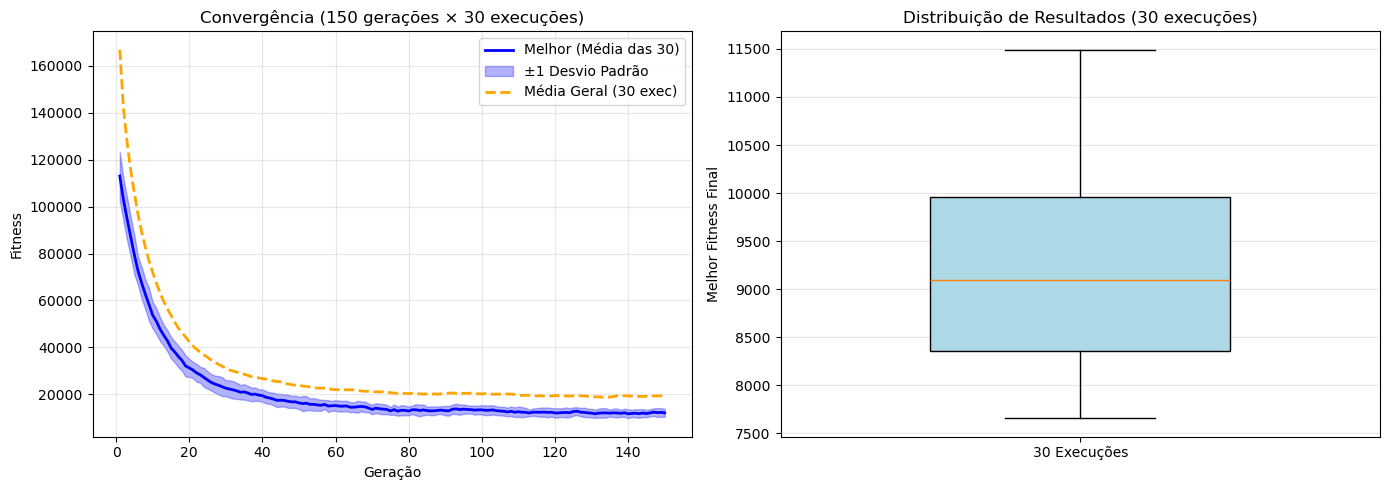

In [63]:
# Consolidar dados das 30 execuções
# Calcular média do melhor fitness por geração (média das 30 execuções)
melhor_por_geracao = []
for geracao in range(n_geracoes):
    valores = [historico[geracao] for historico in historico_melhor_all]
    melhor_por_geracao.append(np.mean(valores))

# Calcular média geral por geração (média de todos os indivíduos em todas as execuções)
media_geral_por_geracao = []
for geracao in range(n_geracoes):
    valores = []
    for historico in historico_notas_all:
        valores.extend(historico[geracao])
    media_geral_por_geracao.append(np.mean(valores))

# Calcular desvio padrão do melhor fitness por geração
desvio_melhor = []
for geracao in range(n_geracoes):
    valores = [historico[geracao] for historico in historico_melhor_all]
    desvio_melhor.append(np.std(valores))

# Criar figura com 2 subplots
plt.figure(figsize=(14, 5))

# Gráfico 1: Convergência consolidada das 30 execuções
plt.subplot(1, 2, 1)
plt.plot(range(1, n_geracoes+1), melhor_por_geracao, label="Melhor (Média das 30)", linewidth=2, color='blue')
plt.fill_between(range(1, n_geracoes+1), 
                  np.array(melhor_por_geracao) - np.array(desvio_melhor),
                  np.array(melhor_por_geracao) + np.array(desvio_melhor),
                  alpha=0.3, label="±1 Desvio Padrão", color='blue')
plt.plot(range(1, n_geracoes+1), media_geral_por_geracao, label="Média Geral (30 exec)", linestyle="--", linewidth=2, color='orange')
plt.xlabel("Geração")
plt.ylabel("Fitness")
plt.title(f"Convergência ({n_geracoes} gerações × 30 execuções)")
plt.legend()
plt.grid(True, alpha=0.3)

# Gráfico 2: Boxplot das 30 execuções
plt.subplot(1, 2, 2)
bp = plt.boxplot([melhor_fitness_por_exec], labels=['30 Execuções'], patch_artist=True, widths=0.5)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
plt.ylabel("Melhor Fitness Final")
plt.title("Distribuição de Resultados (30 execuções)")
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()